**Importing Libraries**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Loading Raw Datasets**

In [37]:
assessments=pd.read_csv('data/assessments.csv')
courses=pd.read_csv('data/courses.csv')
studentassessments=pd.read_csv('data/studentAssessment.csv')
studentinfo=pd.read_csv('data/studentInfo.csv')
studentregistrations=pd.read_csv('data/studentRegistration.csv')
studentvle=pd.read_csv('data/studentVle.csv')
vle=pd.read_csv('data/vle.csv')

In [38]:
df=pd.read_csv('data/encoded_unsupervised.csv')

In [39]:
df.columns

Index(['id_student', 'highest_education', 'imd_band', 'age_band',
       'num_of_prev_attempts', 'studied_credits', 'date_registration',
       'avg_clicks_per_day', 'module_presentation_length',
       'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count',
       'avg_submission_delay', 'sites_revisit_ratio',
       'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC',
       'code_module_DDD', 'code_module_EEE', 'code_module_FFF',
       'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B',
       'code_presentation_2014J', 'gender_M', 'disability_Y'],
      dtype='str')

In [40]:
n_cols = len(df.columns)
print("Number of columns:", n_cols)

Number of columns: 26


In [41]:
import numpy as np

# df = your current feature-engineered dataset

eps = 1e-6  # prevents divide-by-zero

# 1) Late submission ratio (time-management discipline)
df['late_submission_ratio'] = df['late_submissions_count'] / (df['total_submissions'] + eps)

# 2) On-time submission ratio (reliability)
df['on_time_submission_ratio'] = 1 - df['late_submission_ratio']

# 3) Submissions per week (assessment consistency)
df['submissions_per_week'] = df['total_submissions'] / (df['module_presentation_length'] / 7 + eps)

# 4) Late submissions per week (chronic procrastination)
df['late_per_week'] = df['late_submissions_count'] / (df['module_presentation_length'] / 7 + eps)

# 5) Engagement per credit (effort relative to workload)
df['engagement_per_credit'] = df['avg_clicks_per_day'] / (df['studied_credits'] + eps)

# 6) Score per submission (efficiency of attempts)
df['score_per_submission'] = df['tma_cma_weighted_score'] / (df['total_submissions'] + eps)

# 7) Effort-to-score ratio (hard-working vs efficient learners)
df['effort_to_score_ratio'] = df['avg_clicks_per_day'] / (df['tma_cma_weighted_score'] + 1)

# 8) Procrastination index (severity of late behaviour)
df['procrastination_index'] = (
    df['late_submission_ratio'] * df['avg_submission_delay'].clip(lower=0)
)

# 9) Revision intensity (revision behaviour scaled by engagement)
df['revision_intensity'] = df['sites_revisit_ratio'] * df['avg_clicks_per_day']

# 10) Learning breadth score (diversity + engagement combined)
df['learning_breadth_score'] = df['activity_diversity_ratio'] * df['avg_clicks_per_day']

# Cleanup for clustering safety
new_cols = [
    'id_student','late_submission_ratio','on_time_submission_ratio','submissions_per_week','late_per_week',
    'engagement_per_credit','score_per_submission','effort_to_score_ratio','procrastination_index',
    'revision_intensity','learning_breadth_score'
]

df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

df[new_cols].head()


,id_student,late_submission_ratio,on_time_submission_ratio,submissions_per_week,late_per_week,engagement_per_credit,score_per_submission,effort_to_score_ratio,procrastination_index,revision_intensity,learning_breadth_score
0,11391,-8.283661e+05,8.283671e+05,0.000000,-6.376980,0.255025,824000.0,0.419450,-0.000000e+00,-0.039385,0.283106
1,28400,6.513253e+05,-6.513243e+05,0.000000,5.014073,132222.902941,654000.0,0.079941,0.000000e+00,0.060339,0.122355
2,30268,1.325388e+00,-3.253879e-01,-4.811414,-6.376980,309506.981485,-0.0,0.309507,0.000000e+00,-0.038302,-0.081058
3,31604,-8.283661e+05,8.283671e+05,0.000000,-6.376980,105179.523926,763000.0,0.059659,-0.000000e+00,0.153998,0.093302
4,32885,1.584907e+06,-1.584906e+06,0.000000,12.201028,-147293.813000,550000.0,-0.095028,3.819731e+06,-0.095698,-0.085531


In [42]:
n_cols = len(df.columns)
print("Number of columns:", n_cols)

Number of columns: 36


In [43]:
df.head()

,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,...,late_submission_ratio,on_time_submission_ratio,submissions_per_week,late_per_week,engagement_per_credit,score_per_submission,effort_to_score_ratio,procrastination_index,revision_intensity,learning_breadth_score
0,11391,0.75,1.000000,1.0,-0.368196,3.0,-1.818699,0.765076,0.909289,0.824,...,-8.283661e+05,8.283671e+05,0.000000,-6.376980,0.255025,824000.0,0.419450,-0.000000e+00,-0.039385,0.283106
1,28400,0.75,0.222222,0.5,-0.368196,0.0,0.333158,0.132223,0.909289,0.654,...,6.513253e+05,-6.513243e+05,0.000000,5.014073,132222.902941,654000.0,0.079941,0.000000e+00,0.060339,0.122355
2,30268,0.50,0.333333,0.5,-0.368196,0.0,-0.458563,0.309507,0.909289,0.000,...,1.325388e+00,-3.253879e-01,-4.811414,-6.376980,309506.981485,-0.0,0.309507,0.000000e+00,-0.038302,-0.081058
3,31604,0.50,0.555556,0.5,-0.368196,0.0,0.353459,0.105180,0.909289,0.763,...,-8.283661e+05,8.283671e+05,0.000000,-6.376980,105179.523926,763000.0,0.059659,-0.000000e+00,0.153998,0.093302
4,32885,0.25,0.555556,0.0,-0.368196,0.0,-2.163809,-0.147294,0.909289,0.550,...,1.584907e+06,-1.584906e+06,0.000000,12.201028,-147293.813000,550000.0,-0.095028,3.819731e+06,-0.095698,-0.085531


In [44]:
df.columns

Index(['id_student', 'highest_education', 'imd_band', 'age_band',
       'num_of_prev_attempts', 'studied_credits', 'date_registration',
       'avg_clicks_per_day', 'module_presentation_length',
       'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count',
       'avg_submission_delay', 'sites_revisit_ratio',
       'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC',
       'code_module_DDD', 'code_module_EEE', 'code_module_FFF',
       'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B',
       'code_presentation_2014J', 'gender_M', 'disability_Y',
       'late_submission_ratio', 'on_time_submission_ratio',
       'submissions_per_week', 'late_per_week', 'engagement_per_credit',
       'score_per_submission', 'effort_to_score_ratio',
       'procrastination_index', 'revision_intensity',
       'learning_breadth_score'],
      dtype='str')

**Training**

In [45]:
final_features = [
    'avg_clicks_per_day',
    'activity_diversity_ratio',
    'sites_revisit_ratio',
    'late_submission_ratio',
    'avg_submission_delay',
    'procrastination_index',
    'total_submissions',
    'score_per_submission',
    'effort_to_score_ratio'
]

In [46]:
from sklearn.preprocessing import StandardScaler
df = df.set_index("id_student")
X = df[final_features]
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,        # 把 id_student 接回去
    columns=X.columns
)


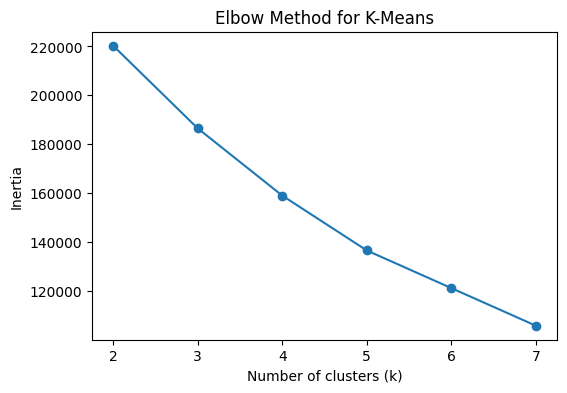

In [47]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
 
inertia = []
k_range = range(2, 8)
 
for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
 
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()
 

In [48]:
# after scaling and after deciding k = 4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

df['cluster'] = kmeans_final.fit_predict(X_scaled)


In [52]:
X_scaled.index.is_unique
dup_ids = X_scaled.index[X_scaled.index.duplicated()].unique()
dup_ids[:10]

Index([65002, 94961, 129955, 135335, 135400, 141377, 147756, 148993, 155984,
       159954],
      dtype='int64', name='id_student')

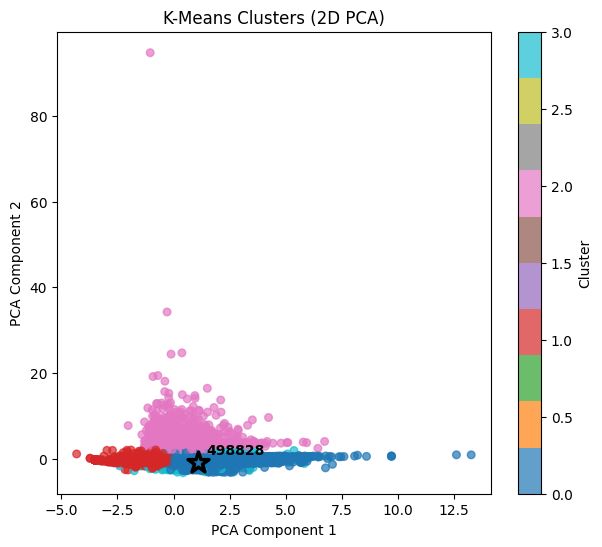

Explained variance (2D): 0.523068219115487


In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 确保 X_scaled 是 DataFrame 且 index = df.index (id_student)
# 例如你之前做过：df = df.set_index("id_student")
# 并且 X_scaled = pd.DataFrame(X_scaled_array, index=df.index, columns=feature_cols)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled.values)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=30
)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('K-Means Clusters (2D PCA)')
plt.colorbar(sc, ax=ax, label='Cluster')

def highlight_student(student_id, annotate=True):
    loc = X_scaled.index.get_loc(student_id)

    # loc 可能是 int / slice / bool-array / int-array
    if isinstance(loc, slice):
        i = loc.start
    elif np.isscalar(loc):
        i = int(loc)
    else:
        # array-like，取第一个
        loc = np.asarray(loc)
        i = int(loc[0])

    x = float(X_pca2[i, 0])
    y = float(X_pca2[i, 1])

    plt.scatter(
        x, y,
        s=250,
        marker='*',
        facecolors='none',
        edgecolors='black',
        linewidths=2.5,
        zorder=10
    )

    if annotate:
        plt.annotate(
            str(student_id),
            (x, y),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=10,
            weight='bold',
            zorder=11
        )

# 你想查哪个学生就改这里
highlight_student(498828)

plt.show()
print("Explained variance (2D):", pca2.explained_variance_ratio_.sum())


umap

In [ ]:
cluster_profile = df.groupby('cluster')[final_features].mean()
cluster_profile

In [ ]:
cluster_profile_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
cluster_profile_z


In [ ]:
cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_sizes
